# 04 — Model Evaluation

## Smart India Real Estate Analytics

### Objective
Evaluate the trained XGBoost regression model on the unseen test dataset.

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Important
The test dataset was not used during model training.

In [3]:

import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [4]:
MODEL_DIR = Path("../models")

model = joblib.load(
    MODEL_DIR / "xgboost_model.joblib"
)

X_test_processed = joblib.load(
    MODEL_DIR / "X_test_processed.joblib"
)

y_test = joblib.load(
    MODEL_DIR / "y_test.joblib"
)

print("Model and test data loaded successfully.")
print("Test features:", X_test_processed.shape)
print("Test target:", y_test.shape)

Model and test data loaded successfully.
Test features: (2904, 6026)
Test target: (2904,)


In [4]:
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.
Number of predictions: 2904

First 10 predictions:
[1.9046990e+07 4.4020210e+06 4.1800132e+07 4.2262525e+06 6.4681145e+06
 1.2052871e+07 7.8161490e+06 4.4020210e+06 1.2914327e+07 1.6807086e+07]


In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("XGBoost Test Set Evaluation")
print("=" * 45)

print(f"MAE :  ₹{mae:,.2f}")
print(f"RMSE:  ₹{rmse:,.2f}")
print(f"R²  :  {r2:.4f}")

XGBoost Test Set Evaluation
MAE :  ₹5,695,869.39
RMSE:  ₹17,352,118.59
R²  :  -0.0659


In [6]:
print("Actual price statistics:")
print(y_test.describe())

print("\nPredicted price statistics:")
print(pd.Series(y_pred).describe())

Actual price statistics:
count    2.904000e+03
mean     1.064120e+07
std      1.680975e+07
min      1.000000e+05
25%      3.800000e+06
50%      6.500000e+06
75%      1.142500e+07
max      3.000000e+08
Name: Price_numeric, dtype: float64

Predicted price statistics:
count    2.904000e+03
mean     1.036552e+07
std      1.360297e+07
min      3.594830e+06
25%      4.904046e+06
50%      6.468114e+06
75%      1.152549e+07
max      5.525923e+08
dtype: float64


In [7]:
y_train = joblib.load(
    MODEL_DIR / "y_train.joblib"
)

print("Training target loaded.")
print("Training target shape:", y_train.shape)

Training target loaded.
Training target shape: (11613,)


In [8]:
baseline_prediction = y_train.mean()

baseline_mae = mean_absolute_error(
    y_test,
    [baseline_prediction] * len(y_test)
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        [baseline_prediction] * len(y_test)
    )
)

baseline_r2 = r2_score(
    y_test,
    [baseline_prediction] * len(y_test)
)

print("Mean Price Baseline")
print("=" * 40)
print(f"MAE :  ₹{baseline_mae:,.2f}")
print(f"RMSE:  ₹{baseline_rmse:,.2f}")
print(f"R²  :  {baseline_r2:.4f}")

Mean Price Baseline
MAE :  ₹8,041,225.23
RMSE:  ₹16,806,917.49
R²  :  -0.0000


## Experiment 2 — Log-Target XGBoost Evaluation

The model was trained using a log-transformed target:

`log1p(Price)`

Predictions are converted back to the original price scale using:

`expm1()`

The resulting predictions are evaluated against the original test prices using MAE, RMSE, and R².

In [9]:
# Load Experiment 2 model

model_log = joblib.load(
    MODEL_DIR / "xgboost_log_target_model.joblib"
)

print("Log-target XGBoost model loaded successfully.")

Log-target XGBoost model loaded successfully.


In [10]:
# Generate predictions in log scale
y_pred_log = model_log.predict(X_test_processed)

# Convert predictions back to original price scale
y_pred_log_original = np.expm1(y_pred_log)

print("Log-target predictions generated successfully.")
print("Number of predictions:", len(y_pred_log_original))

Log-target predictions generated successfully.
Number of predictions: 2904


In [11]:
mae_log = mean_absolute_error(
    y_test,
    y_pred_log_original
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

r2_log = r2_score(
    y_test,
    y_pred_log_original
)

print("=" * 45)
print("Log-Target XGBoost Evaluation")
print("=" * 45)

print(f"MAE :  ₹{mae_log:,.2f}")
print(f"RMSE:  ₹{rmse_log:,.2f}")
print(f"R²  :  {r2_log:.4f}")

Log-Target XGBoost Evaluation
MAE :  ₹4,897,341.79
RMSE:  ₹13,856,375.40
R²  :  0.3203


## Experiment 2 — Conclusion

The log-target XGBoost model significantly outperformed the original-target XGBoost model.

By applying `log1p()` to the highly right-skewed `Price_numeric` target, the model achieved:

- MAE: ₹48.97 lakh
- RMSE: ₹1.386 crore
- R²: 0.3203

Compared with the baseline XGBoost model, both MAE and RMSE decreased, while R² improved substantially from -0.0659 to 0.3203.

The log-target XGBoost model is therefore selected as the current best model.

## Experiment 3 — Error Analysis

The selected log-target XGBoost model is further analyzed using actual versus predicted prices.

This analysis helps identify whether the model systematically overestimates or underestimates property prices and whether prediction errors increase for expensive properties.

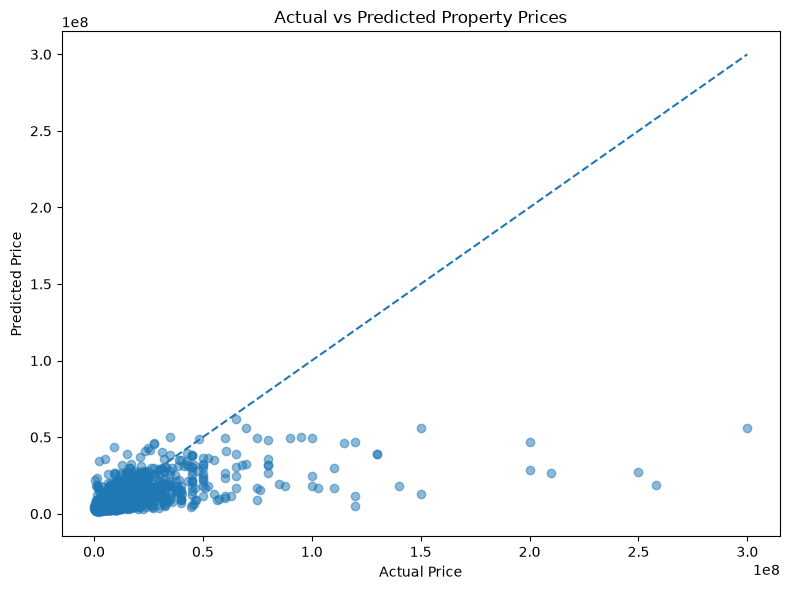

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_log_original, alpha=0.5)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_log_original.min())
max_price = max(y_test.max(), y_pred_log_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Property Prices")

plt.tight_layout()
plt.show()

In [13]:
residuals = y_test - y_pred_log_original

print("Mean Residual:", residuals.mean())
print("Median Residual:", residuals.median())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: 2211054.550878099
Median Residual: -332005.375
Minimum Residual: -34338372.0
Maximum Residual: 244252572.0


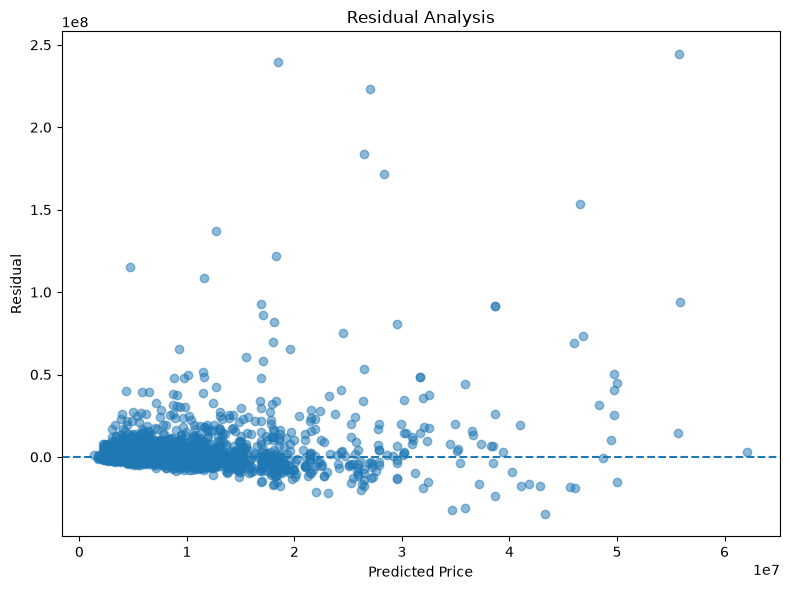

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred_log_original, residuals, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## Experiment 4 — Error Analysis by Price Range

The prediction error is analyzed across different actual property-price ranges.

This helps determine whether model performance changes significantly for lower-priced, mid-range, and high-priced properties.

In [15]:
import pandas as pd
import numpy as np

error_analysis = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred_log_original
})

error_analysis["Absolute_Error"] = (
    error_analysis["Actual_Price"] -
    error_analysis["Predicted_Price"]
).abs()

error_analysis["Price_Range"] = pd.cut(
    error_analysis["Actual_Price"],
    bins=[0, 50_00_000, 1_00_00_000, 2_00_00_000, np.inf],
    labels=[
        "Below ₹50L",
        "₹50L–₹1Cr",
        "₹1Cr–₹2Cr",
        "Above ₹2Cr"
    ]
)

range_summary = error_analysis.groupby(
    "Price_Range",
    observed=True
)["Absolute_Error"].agg(
    Count="count",
    MAE="mean"
)

range_summary

,Count,MAE
Price_Range,,
Below ₹50L,1106,1.755095e+06
₹50L–₹1Cr,992,2.256185e+06
₹1Cr–₹2Cr,525,5.282688e+06
Above ₹2Cr,281,2.586903e+07


In [16]:
range_summary["MAE_Lakh"] = range_summary["MAE"] / 1_00_000

range_summary

,Count,MAE,MAE_Lakh
Price_Range,,,
Below ₹50L,1106,1.755095e+06,17.550953
₹50L–₹1Cr,992,2.256185e+06,22.561854
₹1Cr–₹2Cr,525,5.282688e+06,52.826885
Above ₹2Cr,281,2.586903e+07,258.690314


## Final Model Evaluation

The selected XGBoost model is retrained using the complete training dataset after model selection based on the validation set.

The final model is evaluated on the previously untouched test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The predictions are converted back from the logarithmic scale to the original price scale using `expm1()` before calculating the evaluation metrics.

In [5]:
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_model = joblib.load(
    "../models/xgboost_final_model.joblib"
)

y_pred_final_log = final_model.predict(X_test_processed)

# Convert predictions back to original price scale
y_pred_final = np.expm1(y_pred_final_log)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : ₹{mae_final:,.2f}")
print(f"RMSE : ₹{rmse_final:,.2f}")
print(f"R²   : {r2_final:.4f}")

Final Model Performance
-----------------------
MAE  : ₹4,847,093.25
RMSE : ₹13,629,108.32
R²   : 0.3424


## Final Evaluation — Conclusion

The final log-target XGBoost model with `max_depth=8` was evaluated on the previously untouched test dataset.

The model achieved:

- MAE: ₹48.47 lakh
- RMSE: ₹1.363 crore
- R²: 0.3424

Compared with the previous log-target XGBoost model with `max_depth=6`, the final model achieved lower MAE and RMSE and a higher R² score.

The final model is therefore selected as the current best-performing model for the Smart India Real Estate Analytics project.

## Final Model Evaluation

The final XGBoost model was trained using the log-transformed target variable and `max_depth=8`.

The model is evaluated on the untouched test dataset using three regression metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted prices.
- **RMSE (Root Mean Squared Error):** Gives greater weight to larger prediction errors.
- **R² Score:** Measures how well the model explains the variation in property prices.

These metrics are calculated on the original price scale after converting the model's log-scale predictions back using `expm1()`.

In [4]:
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load test data
X_test_processed = joblib.load("../models/X_test_processed.joblib")
y_test = joblib.load("../models/y_test.joblib")

# Load final model
final_model = joblib.load("../models/xgboost_final_model.joblib")

# Generate predictions on log scale
y_pred_log = final_model.predict(X_test_processed)

# Convert predictions back to original price scale
y_pred = np.expm1(y_pred_log)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : ₹4,847,093.25
RMSE : ₹13,629,108.32
R²   : 0.3424


## Conclusion

The final XGBoost model was evaluated on the untouched test dataset after converting the log-scale predictions back to the original price scale.

The model achieved:

- **MAE:** ₹48.47 lakh
- **RMSE:** ₹1.363 crore
- **R² Score:** 0.3424

The results show that the model is able to capture a meaningful portion of the variation in property prices. However, the higher RMSE compared with MAE indicates that some properties have considerably larger prediction errors.

These metrics establish the final model's quantitative performance and will be further examined using visual analysis and error analysis.

## Actual vs Predicted Price

The Actual vs Predicted plot is used to visually evaluate how closely the model's predictions match the actual property prices.

The dashed diagonal line represents perfect predictions, where:

**Actual Price = Predicted Price**

Points closer to this line indicate better predictions, while points farther from the line represent larger prediction errors.

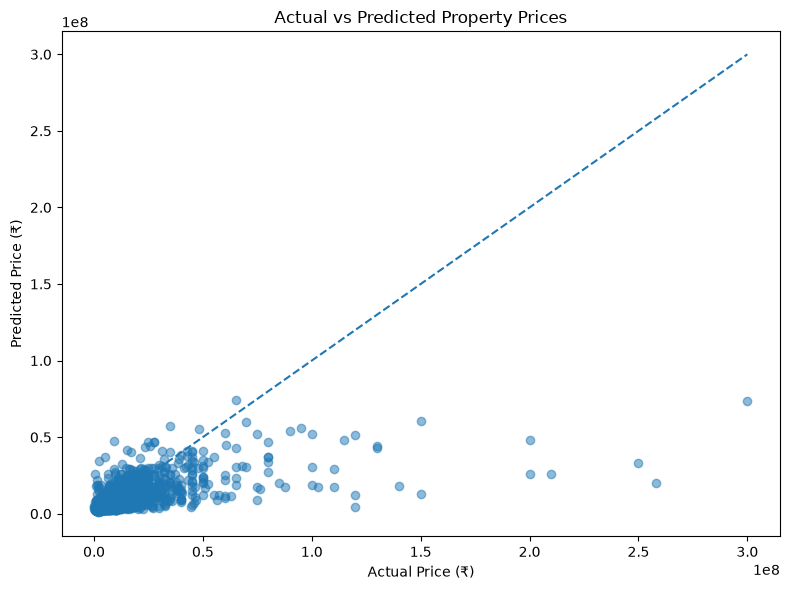

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Property Prices")
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")

plt.tight_layout()
plt.show()

## Conclusion

The Actual vs Predicted plot shows that most predictions are concentrated in the lower-to-mid price range.

Many points are reasonably close to the diagonal reference line, indicating that the model captures general price patterns for a portion of the properties. However, the spread becomes larger as the actual property price increases.

High-priced properties are generally underpredicted, as several points lie substantially below the ideal prediction line. This indicates that the model has difficulty accurately estimating some expensive properties.

Overall, the plot is consistent with the quantitative evaluation, particularly the relatively high RMSE, and shows that prediction errors increase for higher-priced properties.

## Residual Analysis

Residuals represent the difference between the actual and predicted property prices.

They are calculated as:

**Residual = Actual Price − Predicted Price**

The residual plot helps identify systematic prediction errors and determine whether the model consistently overpredicts or underpredicts certain properties.

Ideally, residuals should be distributed around zero without a clear pattern.

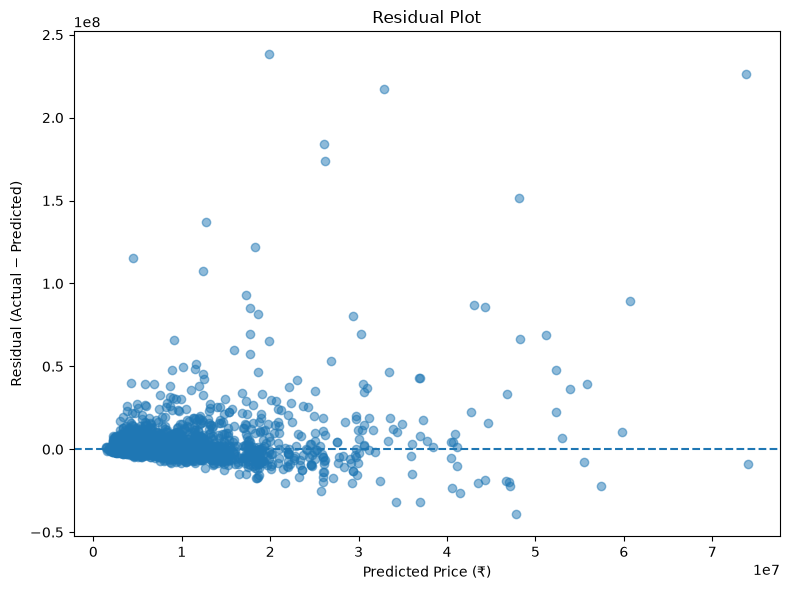

In [6]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Price (₹)")
plt.ylabel("Residual (Actual − Predicted)")

plt.tight_layout()
plt.show()

## Conclusion

The residual plot shows that most prediction errors are concentrated around zero, particularly for lower-priced properties.

However, the spread of residuals increases as the predicted price increases. Several large positive residuals are also visible, indicating that the model substantially underpredicts some high-priced properties.

This pattern suggests that prediction errors are not uniformly distributed across all price ranges. The presence of large residuals for expensive properties also explains the relatively high RMSE observed during model evaluation.

Overall, the residual analysis indicates that the model performs more consistently for lower-priced properties but has greater difficulty estimating high-value properties.

## Error Analysis by Price Range

To understand how model performance varies across different property price levels, the test dataset is divided into four price ranges:

- Below ₹50 lakh
- ₹50 lakh–₹1 crore
- ₹1 crore–₹2 crore
- Above ₹2 crore

The Mean Absolute Error (MAE) is calculated separately for each range.

This analysis helps identify which price segments are predicted more accurately and where the model has greater difficulty.

MAE by Actual Price Range:
Price_Range
Below ₹50L    1.727747e+06
₹50L–₹1Cr     2.258540e+06
₹1Cr–₹2Cr     5.263489e+06
Above ₹2Cr    2.548494e+07
Name: Absolute_Error, dtype: float64


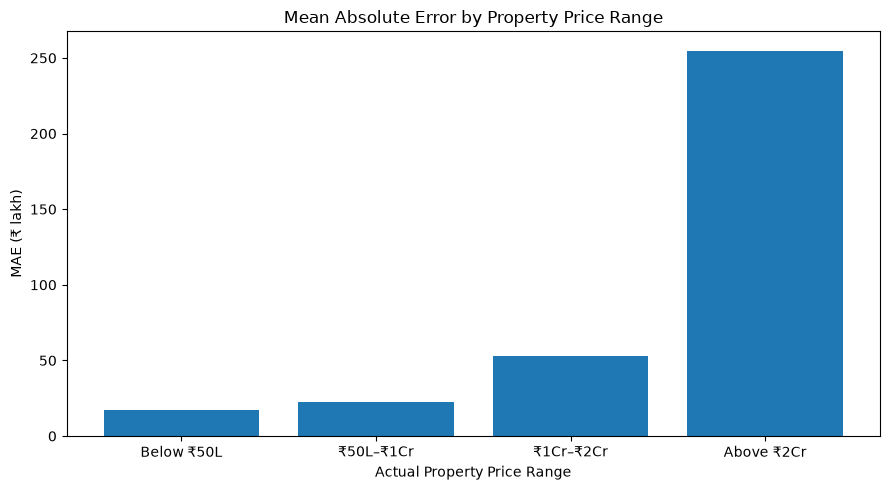

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Create evaluation dataframe
evaluation_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": y_pred
})

# Calculate absolute error
evaluation_df["Absolute_Error"] = abs(
    evaluation_df["Actual_Price"] -
    evaluation_df["Predicted_Price"]
)

# Define price ranges
evaluation_df["Price_Range"] = pd.cut(
    evaluation_df["Actual_Price"],
    bins=[0, 50_00_000, 1_00_00_000, 2_00_00_000, float("inf")],
    labels=[
        "Below ₹50L",
        "₹50L–₹1Cr",
        "₹1Cr–₹2Cr",
        "Above ₹2Cr"
    ]
)

# Calculate MAE for each price range
error_by_range = (
    evaluation_df
    .groupby("Price_Range", observed=False)["Absolute_Error"]
    .mean()
)

print("MAE by Actual Price Range:")
print(error_by_range)

# Plot
plt.figure(figsize=(9, 5))

plt.bar(
    error_by_range.index,
    error_by_range.values / 1e5
)

plt.title("Mean Absolute Error by Property Price Range")
plt.xlabel("Actual Property Price Range")
plt.ylabel("MAE (₹ lakh)")

plt.tight_layout()
plt.show()

## Conclusion

The error analysis shows a clear increase in prediction error as the actual property price increases.

The model achieved an MAE of approximately:

- **₹17.28 lakh** for properties below ₹50 lakh
- **₹22.59 lakh** for properties between ₹50 lakh and ₹1 crore
- **₹52.63 lakh** for properties between ₹1 crore and ₹2 crore
- **₹2.55 crore** for properties above ₹2 crore

The model therefore performs more consistently on lower-priced properties, while high-value properties show substantially larger absolute errors.

This indicates that the current feature set and model have difficulty capturing the factors that differentiate expensive properties. The result also explains the high RMSE observed during overall model evaluation.

## Model Selection Comparison

Two log-target XGBoost models with different tree depths were compared using the validation dataset:

- **Log XGBoost — Depth 6**
- **Log XGBoost — Depth 8**

The models were evaluated using MAE, RMSE, and R².

The validation set was used for model selection so that the final test set remained untouched during model tuning.

The model with the better validation performance was selected as the final model and subsequently evaluated on the test dataset.

In [8]:
import matplotlib.pyplot as plt

# Validation results from model selection
models = [
    "Log XGBoost\nDepth 6",
    "Log XGBoost\nDepth 8"
]

mae_values = [
    52.39,
    52.03
]

rmse_values = [
    172.00,
    171.30
]

r2_values = [
    0.2396,
    0.2460
]

# Display comparison
comparison_df = pd.DataFrame({
    "Model": models,
    "MAE (₹ lakh)": mae_values,
    "RMSE (₹ lakh)": rmse_values,
    "R² Score": r2_values
})

comparison_df

,Model,MAE (₹ lakh),RMSE (₹ lakh),R² Score
0,Log XGBoost\nDepth 6,52.39,172.0,0.2396
1,Log XGBoost\nDepth 8,52.03,171.3,0.2460


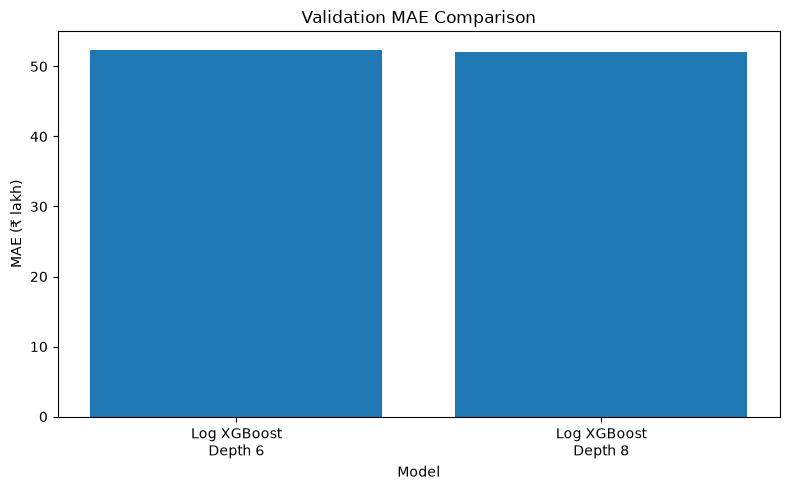

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(models, mae_values)

plt.title("Validation MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE (₹ lakh)")

plt.tight_layout()
plt.show()

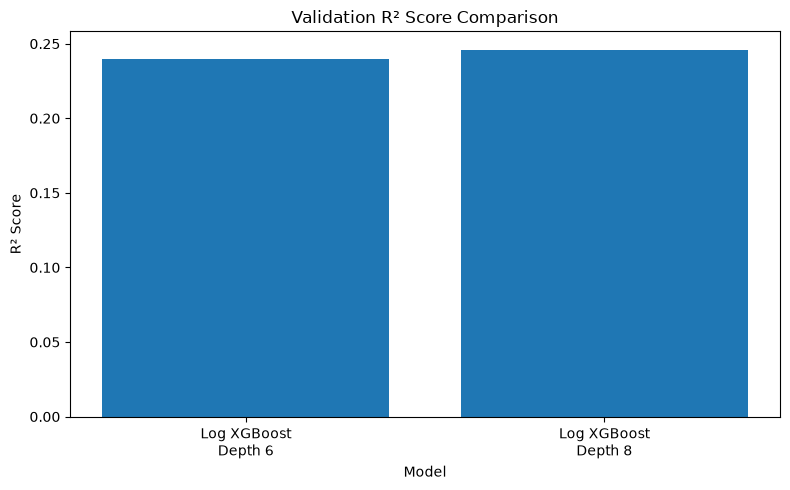

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.title("Validation R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

## Conclusion

The validation comparison shows that the Log XGBoost model with `max_depth=8` performs slightly better than the model with `max_depth=6`.

The Depth 8 model achieved:

- **MAE:** ₹52.03 lakh
- **RMSE:** ₹1.713 crore
- **R² Score:** 0.2460

Compared with Depth 6, it achieved a lower MAE and RMSE and a higher R² score.

Therefore, the **Log XGBoost model with `max_depth=8` was selected as the final model**. It was then retrained using the complete training dataset and evaluated once on the untouched test dataset, where it achieved an R² score of **0.3424**.

This controlled comparison provides a data-driven basis for selecting the final model rather than choosing the model arbitrarily.